# This notebook is only for:

Data analysis
Plotting

Finding threshold

Scientific validation

Think of it as your research lab notebook. 

In [13]:
import os
import sys
import cv2
import dlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imutils import face_utils
from tqdm import tqdm

# ------------------------------------------------
# Base project path
# ------------------------------------------------
BASE_PATH = os.path.expanduser("~/100xDevs/personality/Personality-Classifier")

# Allow importing from src
sys.path.append(BASE_PATH)

# Import geometric feature
from src.feature_extraction.geometric_features import extract_nose_ratio

print("Base Path:", BASE_PATH)

Base Path: /home/yeezy/100xDevs/personality/Personality-Classifier


In [14]:
attr_path = os.path.join(BASE_PATH, "data/raw/ZipCeleb/list_attr_celeba.csv")

data = pd.read_csv(attr_path)

print("Dataset shape:", data.shape)
print(data.head())

Dataset shape: (202599, 41)
     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   
3    -1     -1        -1        -1          -1  ...         -1       -1   
4    -1     -1         1        -1          -1  ...         -1       -1   

   Straight_Hair  Wavy_Hair  Weari

In [15]:
SAMPLE_SIZE = 1000

sample_df = data.sample(n=SAMPLE_SIZE, random_state=42)

print("Sample size:", len(sample_df))

Sample size: 1000


In [16]:
PREDICTOR_PATH = os.path.join(
    BASE_PATH,
    "models/landmark_model/shape_predictor_68_face_landmarks.dat"
)

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PREDICTOR_PATH)

print("Landmark model loaded successfully.")

Landmark model loaded successfully.


In [19]:
ratios = []
labels = []

image_base = os.path.join(BASE_PATH, "data/raw/ZipCeleb/img_align_celeba/img_align_celeba")

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):

    img_path = os.path.join(image_base, row["image_id"])

    image = cv2.imread(img_path)
    if image is None:
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    rects = detector(gray, 1)

    # Only use images with exactly one face
    if len(rects) != 1:
        continue

    shape = predictor(gray, rects[0])
    shape = face_utils.shape_to_np(shape)

    ratio = extract_nose_ratio(shape)

    if ratio is None:
        continue

    ratios.append(ratio)
    labels.append(row["Big_Nose"])

100%|██████████| 1000/1000 [00:33<00:00, 30.05it/s]


In [20]:
ratios = np.array(ratios)
labels = np.array(labels)

print("Valid samples:", len(ratios))

Valid samples: 964


In [21]:
big_nose = ratios[labels == 1]
normal_nose = ratios[labels == -1]

print("Big Nose count:", len(big_nose))
print("Normal Nose count:", len(normal_nose))

Big Nose count: 253
Normal Nose count: 711


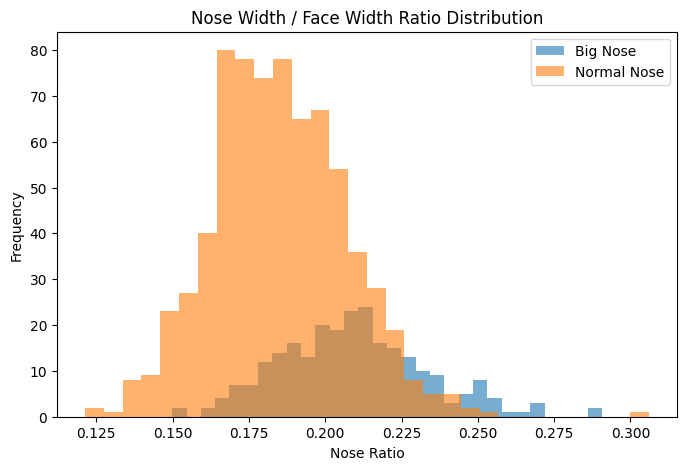

In [22]:
plt.figure(figsize=(8,5))

plt.hist(big_nose, bins=30, alpha=0.6, label="Big Nose")
plt.hist(normal_nose, bins=30, alpha=0.6, label="Normal Nose")

plt.legend()
plt.title("Nose Width / Face Width Ratio Distribution")
plt.xlabel("Nose Ratio")
plt.ylabel("Frequency")

plt.show()

In [23]:
mean_big = big_nose.mean()
mean_normal = normal_nose.mean()

threshold = (mean_big + mean_normal) / 2

print("Mean Big Nose:", mean_big)
print("Mean Normal Nose:", mean_normal)
print("Recommended Threshold:", threshold)

Mean Big Nose: 0.20920463027307862
Mean Normal Nose: 0.1849054903416353
Recommended Threshold: 0.19705506030735698


In [24]:
def evaluate_threshold(thresh):
    predictions = ratios > thresh
    ground_truth = labels == 1
    accuracy = np.mean(predictions == ground_truth)
    return accuracy

acc = evaluate_threshold(threshold)

print("Accuracy using mean threshold:", acc)

Accuracy using mean threshold: 0.7043568464730291


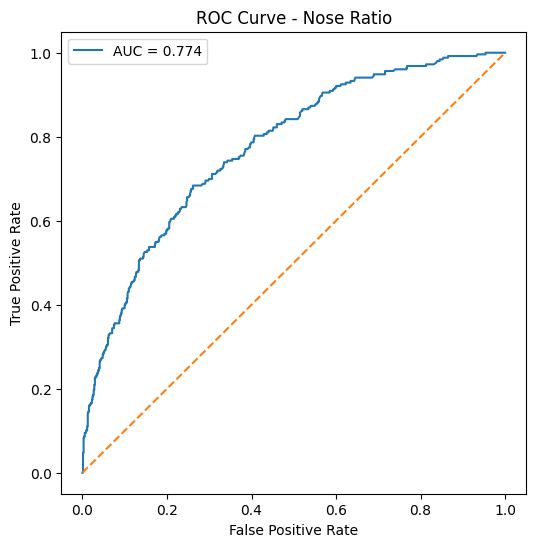

In [25]:
from sklearn.metrics import roc_curve, auc

ground_truth = (labels == 1).astype(int)

fpr, tpr, thresholds = roc_curve(ground_truth, ratios)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Nose Ratio")
plt.legend()
plt.show()

In [26]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("ROC Optimal Threshold:", optimal_threshold)

ROC Optimal Threshold: 0.19799964664709974
